In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

In [4]:
# Load dataset
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["Price"])
y = df["Price"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = model.predict(X_test)


In [11]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("R^2 :" ,model.score(X_test, y_test))

MSE: 0.5678864298646296
R^2 : 0.588233669113432


In [12]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [ 4.35305378e-01  9.63496081e-03 -1.10862824e-01  6.54239488e-01
 -4.99831360e-06 -3.41125112e-03 -4.12503664e-01 -4.24746906e-01]
Intercept: -36.08608764463145


In [13]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(results.head())

    Actual  Predicted
0  1.10400   1.194376
1  2.88100   2.574192
2  1.39700   2.060822
3  5.00001   3.632603
4  4.38900   2.379552


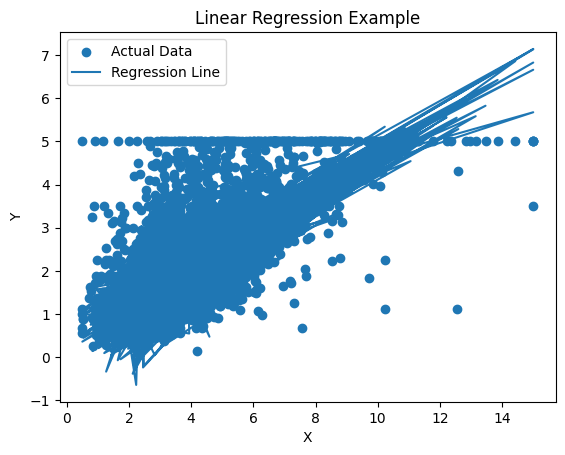

In [14]:
plt.scatter(X_test.iloc[:, 0], y_test, label="Actual Data")
plt.plot(X_test.iloc[:, 0], y_pred, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression Example")
plt.legend()
plt.show()